In [1]:
"""run BC across all sessions"""

import os, sys
from pathlib import Path
import bombcell as bc
import bombcell.quality_metrics as qm
sys.path.append(r"c:\Users\Jasmine\Documents\GitHub\JAL2_subgoal_pipeline")
from behave_analysis.postprocess.bc_process.bombcell_utils import get_waveform_peak_channel_safe
qm.get_waveform_peak_channel = get_waveform_peak_channel_safe
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import matplotlib.colors as mcolors
import json

%matplotlib inline

"""Set up params"""
def get_params(ks_dir, raw_file_path, meta_file_path, mouse):
    param = bc.get_default_parameters(ks_dir, 
                                    raw_file=raw_file_path,
                                    meta_file=meta_file_path,
                                    kilosort_version=2)
    # general params:
    if mouse == "JAL003":
        param["probeType"] = 1  # NP1.0
    else:
        param["probeType"] = 2  # NP2.0

    JR_params = np.load(r"Z:/Jasmine_Laurence/bombcell/bombcell_params.npy", allow_pickle=True).item()
    # Update param with JR_params
    for key, value in JR_params.items():
        param[key] = value

    param["n_spikes"] = 100 # very short sweeps so keep this low low low
        
    return param

"""Run bombcell"""

hist_dict = {}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"] # list of 6 distinct hex colors
metrics = {"nPeaks": 1,
        "nTroughs": 1,
        "waveformBaselineFlatness": .02,
        "waveformDuration_peakTrough": 50,
        "scndPeakToTroughRatio": .02,
        "spatialDecaySlope": .002,
        "peak1ToPeak2Ratio": 5,
        "mainPeakToTroughRatio": .1,
        "rawAmplitude": 15,
        "signalToNoiseRatio": 5,
        "fractionRPVs_estimatedTauR": .05,
        "nSpikes": 10000,
        "presenceRatio": .01,
        "percentageSpikesMissing_gaussian": 1}

base_path = Path(r"Z:/Jasmine_Laurence/Experimental_Data/")

✅ ipywidgets available - interactive GUI ready


In [467]:
mouse = "JAL006" #["JAL003","JAL006", "JAL007"]:
mouse_folder = os.path.join(base_path, mouse)
for i, session in enumerate(os.listdir(mouse_folder)):
    print(f"Processing session: {session}")

Processing session: JAL006_4mar2024_kilosortChanMap.mat
Processing session: JAL006_barrier_flip2_2024_03_18T11_53_29
Processing session: JAL006_empty_shelter_2024_03_04T11_24_29
Processing session: JAL006_Habituation_2024_03_01T13_02_08
Processing session: JAL006_shalter_barrier_flip_2b_2024_03_14T11_21_44
Processing session: JAL006_shalter_barrier_flip_2_2024_03_14T10_35_20
Processing session: JAL006_shelter_barrier_flip_1_11March2024
Processing session: JAL006_shelter_barrier_flip_3_2024_03_21T11_20_34
Processing session: JAL006_shelter_barrier_flip_5_2024_03_25T11_05_33
Processing session: JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20
Processing session: JAL006_shelter_barrier_flip_7_take2_2024_04_01T11_24_46
Processing session: JAL006_shelter_barrier_flip_8_2024_04_05T10_45_20
Processing session: JAL6_chanmap_1march2024.imro
Processing session: JAL6_chanmap_21may2024.imro
Processing session: JAL6_chanmap_4march2024.imro
Processing session: JAL6_chanmap_8march2024.imro
Processin

In [ ]:
ks_params = {"detect_threshold": [], "projection_threshold": [], "AUCsplit": [], "nblocks": [], "default": []}

sesh_idx = 3

mouse_folder = os.path.join(base_path, mouse)
for i, session in enumerate(os.listdir(mouse_folder)):
    if i != sesh_idx:
        continue
    session_folder = os.path.join(mouse_folder, session)
    # find dir that end in "_g0"
    if os.path.isdir(session_folder): #and (session in [seh_list[sesh_idx]]):
        print(f"Processing session: {session}")
        for d in os.listdir(session_folder):
            if os.path.isdir(os.path.join(session_folder, d)) and d.endswith("_g0"):
                for e in os.listdir(os.path.join(session_folder, d, d + "_imec0")):
                    if e == "KS_sweep":
                        imec_folder = os.path.join(session_folder, d, d + "_imec0")
                        raw_file = os.path.join(imec_folder, d + "_t0.imec0.ap.bin")
                        meta_file = os.path.join(imec_folder, d + "_t0.imec0.ap.meta")
                        for run in os.listdir(os.path.join(imec_folder, e)):
                            if "plot" in run or "run" not in run:
                                continue

                            ks_dir = os.path.join(imec_folder, e, run, "sorter_output", "sorter_output")

                            if not os.path.exists(os.path.join(ks_dir, 'cluster_KSlabel.tsv')):
                                print(f"KS output not found for {ks_dir}, skipping...")
                            else:

                                # load params from json
                                if "default" in run:
                                    ks_params["default"].append(True)
                                    json_path = os.path.join(imec_folder, e, run, "sorter_output", "spikeinterface_params.json")
                                    params = json.load(open(json_path))
                                    ks_params["detect_threshold"].append(params["sorter_params"]["detect_threshold"])
                                    ks_params["projection_threshold"].append(params["sorter_params"]["projection_threshold"])
                                    ks_params["AUCsplit"].append(params["sorter_params"]["AUCsplit"])
                                    ks_params["nblocks"].append(params["sorter_params"]["nblocks"])
                                else:
                                    ks_params["default"].append(False)
                                    json_path = os.path.join(imec_folder, e, run, "params.json")
                                    params = json.load(open(json_path))
                                    ks_params["detect_threshold"].append(params["detect_threshold"])
                                    ks_params["projection_threshold"].append(params["projection_threshold"])
                                    ks_params["AUCsplit"].append(params["AUCsplit"])
                                    ks_params["nblocks"].append(params["nblocks"])
                        break

ks_params["used_it"] = np.zeros(len(ks_params["detect_threshold"]), dtype=bool)
default_bool = (np.array(ks_params["detect_threshold"]) == 6) & ((np.array(ks_params["projection_threshold"]) == [8,4]).all(axis=1)) & (np.array(ks_params["AUCsplit"]) == 0.8) & (np.array(ks_params["nblocks"]) == 5)
ks_params["used_it"][np.where(default_bool)[0]] = True
print(f"Number of KS sweeps: {len(ks_params['detect_threshold'])}")
AUCsplit = np.array(ks_params["AUCsplit"]) == 0.8
for dt in [6,7,8,9]:
    pt = np.array(ks_params["projection_threshold"])[(np.array(ks_params["detect_threshold"]) == dt) & AUCsplit,:]
    print(f"Detect threshold {dt}: projection thresholds: {pt}, AUCsplit: 0.8, nblocks: 5")

Processing session: JAL006_barrier_flip2_2024_03_18T11_53_29
Number of KS sweeps: 22
Detect threshold 6: projection thresholds: [[7 3]
 [8 4]
 [6 3]], AUCsplit: 0.8, nblocks: 5
Detect threshold 7: projection thresholds: [[7 3]
 [8 4]
 [6 3]], AUCsplit: 0.8, nblocks: 5
Detect threshold 8: projection thresholds: [[7 3]
 [8 4]
 [6 3]], AUCsplit: 0.8, nblocks: 5
Detect threshold 9: projection thresholds: [[7 3]
 [8 4]
 [6 3]], AUCsplit: 0.8, nblocks: 5


In [468]:
# "detect_threshold": 6
# "projection_threshold": [8, 4]  # Spike detection threshold
# "AUCsplit": 0.8
# "nblock": 5

bc_metrics = {"spikes_missing":[], "rpv":[], "amplitude":[], "snr":[]}
results = {'unit_num': [], 'n_good_units': [], 'n_mua_units': [], 'n_noise_units': [], 'n_spikes': []}
ks_params = {"detect_threshold": [], "projection_threshold": [], "AUCsplit": [], "nblocks": [], "default": []}

sesh_idx = 3 #6-12

# seh_list = ["JAL007_barrier_flip3_2024_03_15T11_20_19"]

mouse = "JAL006"
mouse_folder = os.path.join(base_path, mouse)
for i, session in enumerate(os.listdir(mouse_folder)):
    if i != sesh_idx:
        continue
    session_folder = os.path.join(mouse_folder, session)
    # find dir that end in "_g0"
    if os.path.isdir(session_folder): #and (session in [seh_list[sesh_idx]]):
        print(f"Processing session: {session}")
        for d in os.listdir(session_folder):
            if os.path.isdir(os.path.join(session_folder, d)) and d.endswith("_g0"):
                for e in os.listdir(os.path.join(session_folder, d, d + "_imec0")):
                    if e == "KS_sweep":
                        imec_folder = os.path.join(session_folder, d, d + "_imec0")
                        raw_file = os.path.join(imec_folder, d + "_t0.imec0.ap.bin")
                        meta_file = os.path.join(imec_folder, d + "_t0.imec0.ap.meta")
                        if os.path.exists(os.path.join(imec_folder, "SI_KS_output_og")):
                            if os.path.exists(os.path.join(imec_folder, "SI_KS_output_og","sorter_output", "cluster_bc_unitType.tsv")):
                                og_good_n = np.sum(pd.read_csv(os.path.join(imec_folder, "SI_KS_output_og","sorter_output", "cluster_bc_unitType.tsv"), sep='\t')['bc_unitType'].to_numpy() == "GOOD")
                            else:
                                og_good_n = 0
                            if os.path.exists(os.path.join(imec_folder, "SI_KS_output","sorter_output", "cluster_bc_unitType.tsv")):
                                new_good_n = np.sum(pd.read_csv(os.path.join(imec_folder, "SI_KS_output","sorter_output", "cluster_bc_unitType.tsv"), sep='\t')['bc_unitType'].to_numpy() == "GOOD")
                            else:
                                new_good_n = 0
                        else:
                            new_good_n = 0
                            if os.path.exists(os.path.join(imec_folder, "SI_KS_output","sorter_output", "cluster_bc_unitType.tsv")):
                                og_good_n = np.sum(pd.read_csv(os.path.join(imec_folder, "SI_KS_output","sorter_output", "cluster_bc_unitType.tsv"), sep='\t')['bc_unitType'].to_numpy() == "GOOD")
                            else:
                                og_good_n = 0

                        for run in os.listdir(os.path.join(imec_folder, e)):
                            if "plot" in run or "run" not in run:
                                continue
                            # print(f"Processing run: {run}")

                            ks_dir = os.path.join(imec_folder, e, run, "sorter_output", "sorter_output")

                            # Set bombcell's output directory
                            save_path = Path(ks_dir) / "bombcell"
                            if not os.path.exists(save_path):
                                print(f"You have not yet run bombcell for session {session} ({d}): {run}. Go run it on the cluster!")

                            else:
                                # load params from json
                                if "default" in run:
                                    ks_params["default"].append(True)
                                    json_path = os.path.join(imec_folder, e, run, "sorter_output", "spikeinterface_params.json")
                                    params = json.load(open(json_path))
                                    ks_params["detect_threshold"].append(params["sorter_params"]["detect_threshold"])
                                    ks_params["projection_threshold"].append(params["sorter_params"]["projection_threshold"])
                                    ks_params["AUCsplit"].append(params["sorter_params"]["AUCsplit"])
                                    ks_params["nblocks"].append(params["sorter_params"]["nblocks"])
                                else:
                                    ks_params["default"].append(False)
                                    json_path = os.path.join(imec_folder, e, run, "params.json")
                                    params = json.load(open(json_path))
                                    ks_params["detect_threshold"].append(params["detect_threshold"])
                                    ks_params["projection_threshold"].append(params["projection_threshold"])
                                    ks_params["AUCsplit"].append(params["AUCsplit"])
                                    ks_params["nblocks"].append(params["nblocks"])
                                types = pd.read_csv(os.path.join(ks_dir, "cluster_bc_unitType.tsv"), sep='\t')
                                results['unit_num'].append(len(types))
                                results['n_good_units'].append(np.sum(types['bc_unitType'].to_numpy() == "GOOD"))
                                results['n_mua_units'].append(np.sum(types['bc_unitType'].to_numpy() == "MUA"))
                                results['n_noise_units'].append(np.sum(types['bc_unitType'].to_numpy() == "NOISE"))
                                # chosen = np.ones(len(types), dtype=bool)  
                                chosen = types['bc_unitType'].to_numpy() == "GOOD"
                                spike_clusters = np.load(os.path.join(ks_dir, "spike_clusters.npy"))
                                results['n_spikes'].append(len(spike_clusters))
                                rpv = pd.read_csv(os.path.join(ks_dir, "cluster_fractionRPVs_estimatedTauR.tsv"), sep='\t')
                                bc_metrics["rpv"].append(np.nanpercentile(rpv['fractionRPVs_estimatedTauR'].to_numpy()[chosen], 50))
                                sm = pd.read_csv(os.path.join(ks_dir, "cluster_percentageSpikesMissing_gaussian.tsv"), sep='\t')
                                bc_metrics["spikes_missing"].append(np.nanpercentile(sm['percentageSpikesMissing_gaussian'].to_numpy()[chosen], 50))
                                bc_metrics["amplitude"].append(np.nanpercentile(pd.read_csv(os.path.join(ks_dir, "cluster_rawAmplitude.tsv"), sep='\t')['rawAmplitude'].to_numpy()[chosen], 50))
                                bc_metrics["snr"].append(np.nanpercentile(pd.read_csv(os.path.join(ks_dir, "cluster_signalToNoiseRatio.tsv"), sep='\t')['signalToNoiseRatio'].to_numpy()[chosen], 50))
                        break

ks_params["used_it"] = np.zeros(len(ks_params["detect_threshold"]), dtype=bool)
default_bool = (np.array(ks_params["detect_threshold"]) == 6) & ((np.array(ks_params["projection_threshold"]) == [8,4]).all(axis=1)) & (np.array(ks_params["AUCsplit"]) == 0.8) & (np.array(ks_params["nblocks"]) == 5)
ks_params["used_it"][np.where(default_bool)[0]] = True
print(f"Number of KS sweeps: {len(ks_params['detect_threshold'])}")

Processing session: JAL006_Habituation_2024_03_01T13_02_08
Number of KS sweeps: 22


In [3]:
def n_shades(base_color, n=3, light_mix=0.65, dark_mix=0.35):
    """
    Return n shades from light to dark for a base color.
    n=1 returns the base color.
    """
    base = np.array(mcolors.to_rgb(base_color))

    if n <= 1:
        return [mcolors.to_hex(base)]

    light = base + (1 - base) * light_mix
    dark = base * dark_mix

    shades = [mcolors.to_hex(c) for c in np.linspace(light, dark, n)]
    return shades

Ideal iteration 0: n_blocks=5, detect_threshold=6, projection_threshold=[7 3], AUCsplit=0.8
Ideal iteration 6: n_blocks=5, detect_threshold=9, projection_threshold=[7 3], AUCsplit=0.8
Unique ideal params | n_blocks=[5], detect_threshold=[6 9], projection_threshold=[[7 3]], AUCsplit=[0.8]
Good unit counts: og_param=45, default=32, ideal=[48 48]


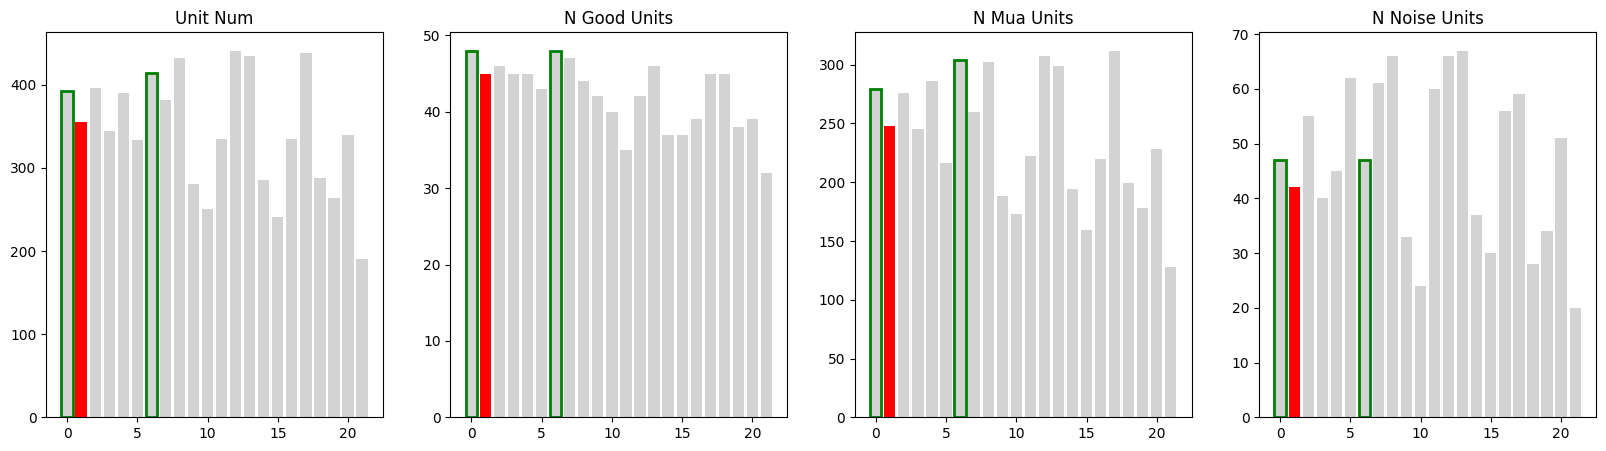

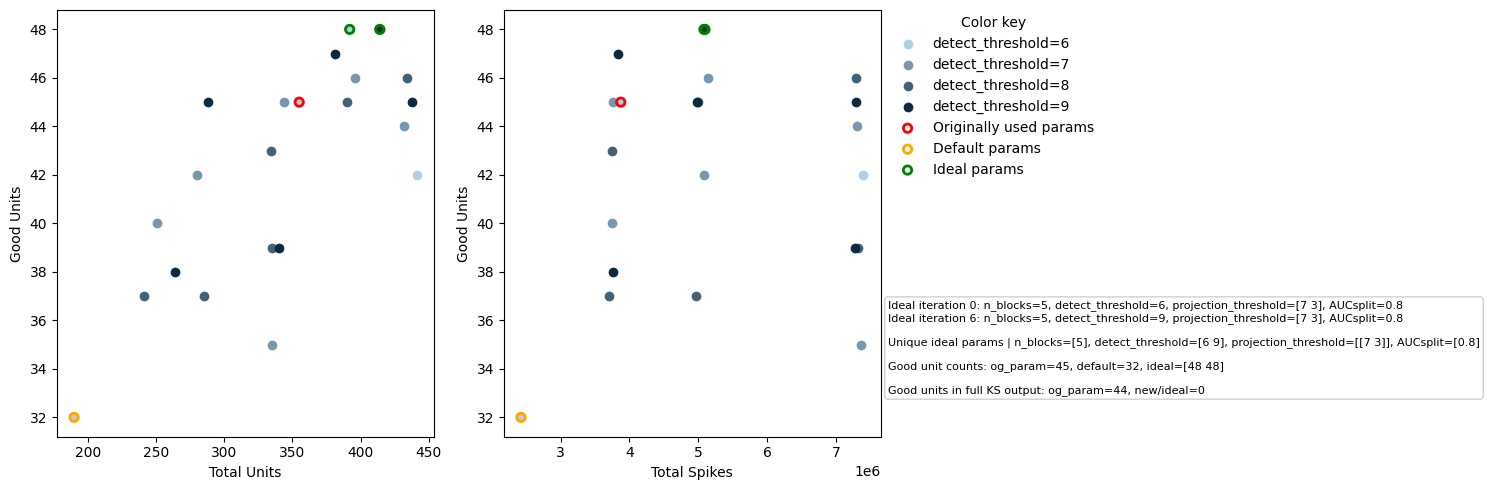

In [469]:
"""Plot the results"""
param_to_view = "detect_threshold"  # can be projection_threshold, AUCsplit, nblocks
use_color = np.array(ks_params[param_to_view]) # projection_threshold, AUCsplit, nblocks
shades = n_shades("#1f77b4", n=len(np.unique(use_color, axis=0)))
used_it = np.where(ks_params["used_it"])[0][0]
if len(np.where(ks_params["default"])[0]) == 0:
    default = None
else:
    default = np.where(ks_params["default"])[0][0]
# ideal = np.where((np.array(results["n_good_units"]) > (np.amax(np.array(results["n_good_units"]))-2)) & (np.array(results['unit_num']) < 700))[0]
# ideal = [np.argmax(np.array(results["n_good_units"]))]
ideal = np.where(np.array(results["n_good_units"]) == np.amax(np.array(results["n_good_units"])[np.array(results['unit_num']) < 700]))[0]

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
for n, d in enumerate(["unit_num", "n_good_units", "n_mua_units", "n_noise_units"]):
    axs[n].bar(range(len(results[d])), results[d], color='lightgray')
    axs[n].bar(used_it, results[d][used_it], color='red')  # Highlight the used iteration
    axs[n].bar(np.array(ideal), np.array(results[d])[ideal], edgecolor='green', facecolor='none', linewidth=2)  # Highlight the ideal iterations
    axs[n].set_title(d.replace("_", " ").title())

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
# good vs total units
for i, val in enumerate(np.unique(use_color, axis=0)):
    if isinstance(val, np.ndarray):
        mask = (use_color == val).all(axis=1)
    else:
        mask = use_color == val
    axs[0].scatter(np.array(results['unit_num'])[mask], np.array(results['n_good_units'])[mask], color = shades[i])
axs[0].scatter(results["unit_num"][used_it], results["n_good_units"][used_it], edgecolor='red', facecolor = "None", linewidth = 2, label='Originally used params')  # Highlight the used iteration
if default is not None:
    axs[0].scatter(results["unit_num"][default], results["n_good_units"][default], edgecolor='orange', facecolor = "None", linewidth = 2, label='Default params')  # Highlight the default iteration
axs[0].scatter(np.array(results['unit_num'])[ideal], np.array(results['n_good_units'])[ideal], edgecolor='green', facecolor = "None", linewidth = 2, label='Ideal params')  # Highlight the ideal iterations
axs[0].set_xlabel('Total Units')
axs[0].set_ylabel('Good Units')
# good units vs total spikes
for i, val in enumerate(np.unique(use_color, axis=0)):
    if isinstance(val, np.ndarray):
        mask = (use_color == val).all(axis=1)
    else:
        mask = use_color == val
    axs[1].scatter(np.array(results['n_spikes'])[mask], np.array(results['n_good_units'])[mask], color = shades[i],
        label=f"{param_to_view}={val}")
axs[1].scatter(results["n_spikes"][used_it], results["n_good_units"][used_it], edgecolor='red', facecolor = "None", linewidth = 2, label='Originally used params')  # Highlight the used iteration
if default is not None:
    axs[1].scatter(results["n_spikes"][default], results["n_good_units"][default], edgecolor='orange', facecolor = "None", linewidth = 2, label='Default params')  # Highlight the default iteration
axs[1].scatter(np.array(results['n_spikes'])[ideal], np.array(results['n_good_units'])[ideal], edgecolor='green', facecolor = "None", linewidth = 2, label='Ideal params')  # Highlight the ideal iterations
axs[1].set_xlabel('Total Spikes')
axs[1].set_ylabel('Good Units')
handles, labels = axs[1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axs[1].legend(
    by_label.values(),
    by_label.keys(),
    title="Color key",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=False
)

# Make room on the right for legend + text block
fig.subplots_adjust(right=0.68)

# Build the same lines you currently print, and also draw them on-figure
summary_lines = []
for i in ideal:
    line = (
        f"Ideal iteration {i}: n_blocks={ks_params['nblocks'][i]}, "
        f"detect_threshold={ks_params['detect_threshold'][i]}, "
        f"projection_threshold={np.array(ks_params['projection_threshold'])[i,:]}, "
        f"AUCsplit={ks_params['AUCsplit'][i]}"
    )
    print(line)
    summary_lines.append(line)

aggregate_line = (
    f"Unique ideal params | n_blocks={np.unique(np.array(ks_params['nblocks'])[ideal])}, "
    f"detect_threshold={np.unique(np.array(ks_params['detect_threshold'])[ideal])}, "
    f"projection_threshold={np.unique(np.array(ks_params['projection_threshold'])[ideal, :], axis=0)}, "
    f"AUCsplit={np.unique(np.array(ks_params['AUCsplit'])[ideal])}"
)
print(aggregate_line)
summary_lines.append("")
summary_lines.append(aggregate_line)

good_n_counts_line = f"Good unit counts: og_param={results['n_good_units'][used_it]}, default={results['n_good_units'][default] if default is not None else 'N/A'}, ideal={np.array(results['n_good_units'])[ideal]}"
print(good_n_counts_line)
good_n_counts_fullKS_line = f"Good units in full KS output: og_param={og_good_n}, new/ideal={new_good_n}"
summary_lines.append("")
summary_lines.append(good_n_counts_line)
summary_lines.append("")
summary_lines.append(good_n_counts_fullKS_line)

axs[1].text(
    1.02, 0.32,
    "\n".join(summary_lines),
    transform=axs[1].transAxes,
    ha="left",
    va="top",
    fontsize=8,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor="0.8"),
    clip_on=False
)
plt.tight_layout()
fig.savefig(os.path.join(imec_folder, "KS_sweep", f"ks_sweep_bc_unit_types_{param_to_view}.png"), dpi=300)

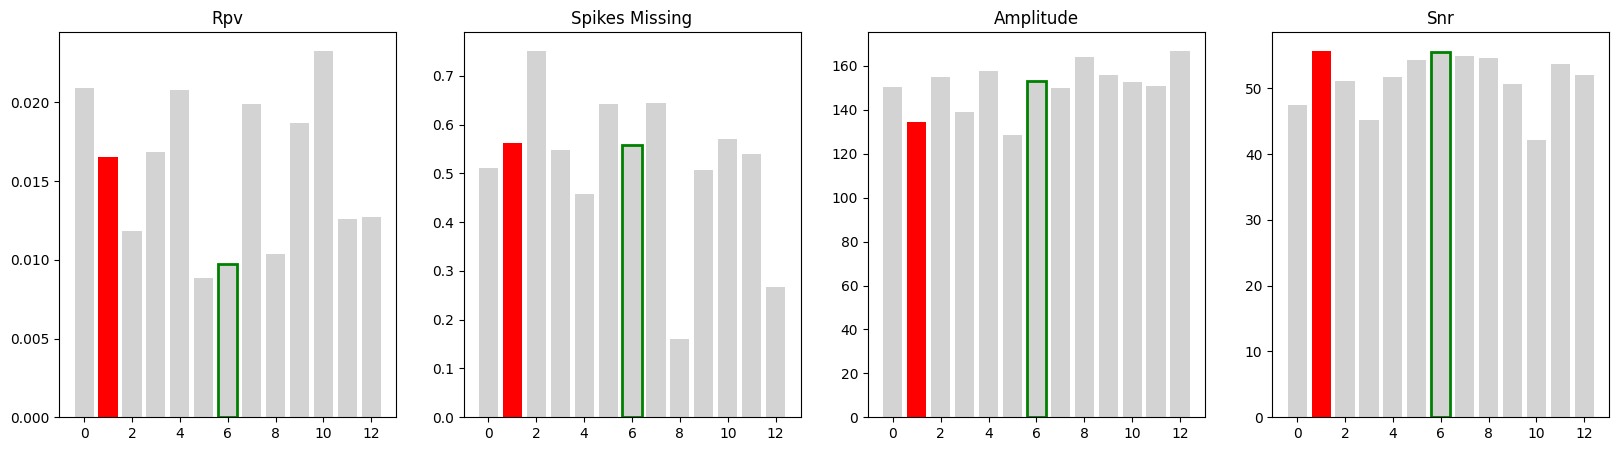

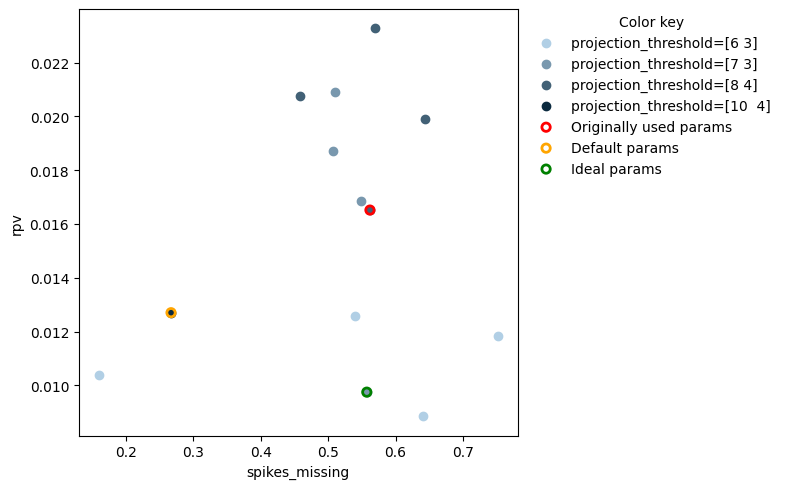

In [460]:
"""Compare metrics"""
param_to_view = "projection_threshold"  # can be projection_threshold, AUCsplit, nblocks
use_color = np.array(ks_params[param_to_view]) # projection_threshold, AUCsplit, nblocks
shades = n_shades("#1f77b4", n=len(np.unique(use_color, axis=0)))
x = 'spikes_missing'
xlim = (0, 10)
y = 'rpv'
ylim = (0, 0.08)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
for n, d in enumerate(["rpv", "spikes_missing", "amplitude", "snr"]):
    axs[n].bar(range(len(bc_metrics[d])), bc_metrics[d], color='lightgray')
    axs[n].bar(used_it, bc_metrics[d][used_it], color='red')  # Highlight the used iteration
    axs[n].bar(np.array(ideal), np.array(bc_metrics[d])[ideal], edgecolor='green', facecolor = "None", linewidth = 2)  # Highlight the ideal iterations
    axs[n].set_title(d.replace("_", " ").title())

fig, axs = plt.subplots(1, 1, figsize=(8, 5))
for i, val in enumerate(np.unique(use_color, axis=0)):
    if isinstance(val, np.ndarray):
        mask = (use_color == val).all(axis=1)
    else:
        mask = use_color == val
    axs.scatter(np.array(bc_metrics[x])[mask], np.array(bc_metrics[y])[mask], color=shades[i],
        label=f"{param_to_view}={val}")
axs.scatter(bc_metrics[x][used_it], bc_metrics[y][used_it], edgecolor='red', facecolor = "None", linewidth = 2, label='Originally used params')  # Highlight the used iteration
if default is not None:
    axs.scatter(bc_metrics[x][default], bc_metrics[y][default], edgecolor='orange', facecolor = "None", linewidth = 2, label='Default params')  # Highlight the default iteration
axs.scatter(np.array(bc_metrics[x])[ideal], np.array(bc_metrics[y])[ideal], edgecolor='green', facecolor = "None", linewidth = 2, label='Ideal params')  # Highlight the ideal iterations
axs.set_xlabel(x)
# axs.set_xlim(xlim)
# axs.set_ylim(ylim)
axs.set_ylabel(y)
handles, labels = axs.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axs.legend(
    by_label.values(),
    by_label.keys(),
    title="Color key",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=False
)
plt.tight_layout()
fig.savefig(os.path.join(imec_folder, "KS_sweep", f"ks_sweep_bc_metrics_{param_to_view}.png"), dpi=300)